##Problem 1 - MLP-based Autoencoder

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [3]:
class Autoencoder(nn.Module):
  def __init__(self):
    super(Autoencoder, self).__init__()

    self.encoder_layer1 = nn.Linear(28*28, 256)
    self.encoder_layer2 = nn.Linear(256, 64)
    self.encoder_layer3 = nn.Linear(64, 16)

    self.decoder_layer1 = nn.Linear(16,64)
    self.decoder_layer2 = nn.Linear(64,256)
    self.decoder_layer3 = nn.Linear(256,28*28)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encoder(self, x):
    x = self.relu(self.encoder_layer1(x))
    x = self.relu(self.encoder_layer2(x))
    x = self.relu(self.encoder_layer3(x))
    return x

  def decoder(self,x):
    x = self.relu(self.decoder_layer1(x))
    x = self.relu(self.decoder_layer2(x))
    x = self.sigmoid(self.decoder_layer3(x))
    return x

  def forward(self,x):
    xe = self.encoder(x)
    x = self.decoder(xe)
    return x

In [5]:
device = torch.device("cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0
  for images,_ in train_loader:
    images = images.view(images.size(0),-1).to(device)
    output = model(images)
    loss = criterion(output, images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch:{epoch}, Loss:{total_loss:.4f}")

Epoch:0, Loss:28.5660
Epoch:1, Loss:15.7396
Epoch:2, Loss:13.2592
Epoch:3, Loss:12.1955
Epoch:4, Loss:11.0972
Epoch:5, Loss:10.4891
Epoch:6, Loss:10.0616
Epoch:7, Loss:9.7468
Epoch:8, Loss:9.5100
Epoch:9, Loss:9.2942


In [8]:
model.eval()
correct,total = 0,0
with torch.no_grad():
  for images,_ in test_loader:
    images = images.view(images.size(0),-1).to(device)
    output = model(images)
    predicted = (output>0.5).float()

    correct += (predicted == images).sum().item()
    total += images.numel()

accuracy = correct/total*100
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 80.92%


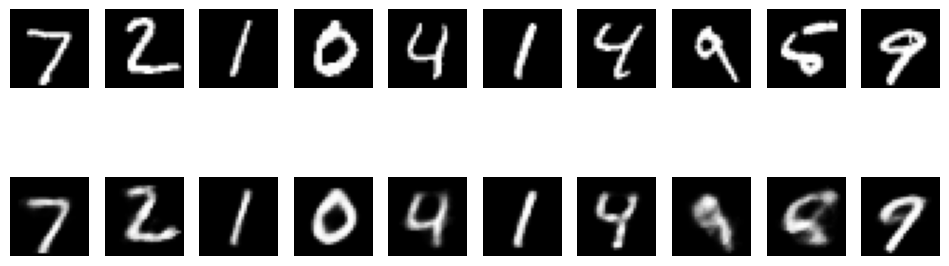

In [11]:
images,_ = next(iter(test_loader))
images = images.view(images.size(0),-1).to(device)

with torch.no_grad():
  outputs = model(images)

images = images.view(-1,1,28,28)
outputs = outputs.view(-1,1,28,28)

plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,10,i+1)
  plt.imshow(images[i].cpu().squeeze(), cmap='gray')
  plt.axis('off')

  plt.subplot(2,10,i+11)
  plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
  plt.axis('off')

plt.show()

##Problem 2 - Classification using an autoencoder

In [18]:
class AutoencoderClassifier(nn.Module):
  def __init__(self):
    super(AutoencoderClassifier, self).__init__()

    self.encoder_layer1 = nn.Linear(28*28, 256)
    self.encoder_layer2 = nn.Linear(256, 64)
    self.encoder_layer3 = nn.Linear(64, 16)

    self.decoder_layer1 = nn.Linear(16,64)
    self.decoder_layer2 = nn.Linear(64,256)
    self.decoder_layer3 = nn.Linear(256,28*28)

    self.classifier = nn.Linear(16,10)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encoder(self, x):
    x = self.relu(self.encoder_layer1(x))
    x = self.relu(self.encoder_layer2(x))
    x = self.relu(self.encoder_layer3(x))
    return x

  def decoder(self,x):
    x = self.relu(self.decoder_layer1(x))
    x = self.relu(self.decoder_layer2(x))
    x = self.sigmoid(self.decoder_layer3(x))
    return x

  def classify(self,xe):
    xe = self.classifier(xe)
    return xe

  def forward(self,x):
    xe = self.encoder(x)
    x1 = self.decoder(xe)
    pred = self.classify(xe)
    return x1,pred

In [19]:
device = torch.device("cpu")
model = AutoencoderClassifier().to(device)
mse_loss = nn.MSELoss()
ce_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0
  for images,labels in train_loader:
    images = images.view(images.size(0),-1).to(device)
    labels = labels.to(device)

    output, pred = model(images)
    loss1 = mse_loss(output, images)
    loss2 = ce_loss(pred, labels)
    loss = loss1 + loss2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch:{epoch}, Loss:{total_loss:.4f}")

Epoch:0, Loss:251.3292
Epoch:1, Loss:99.9650
Epoch:2, Loss:71.4410
Epoch:3, Loss:56.3622
Epoch:4, Loss:46.4590
Epoch:5, Loss:39.2024
Epoch:6, Loss:34.4702
Epoch:7, Loss:29.9129
Epoch:8, Loss:26.7350
Epoch:9, Loss:22.7478


In [22]:
model.eval()
correct,total = 0,0
with torch.no_grad():
  for images,labels in test_loader:
    images = images.view(images.size(0),-1).to(device)
    labels = labels.to(device)
    output = model.encoder(images)
    pred = model.classify(output)
    _,predicted = torch.max(pred,1)

    correct += (predicted == labels).sum().item()
    total += labels.size(0)

accuracy = correct/total*100
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 98.06%


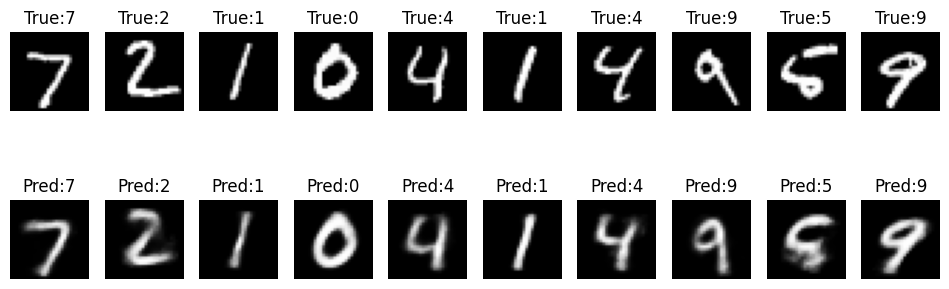

In [26]:
images,labels = next(iter(test_loader))
images = images.view(images.size(0),-1).to(device)

with torch.no_grad():
  outputs,pred = model(images)
  _,predicted = torch.max(pred,1)

images = images.view(-1,1,28,28)
outputs = outputs.view(-1,1,28,28)

plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,10,i+1)
  plt.imshow(images[i].cpu().squeeze(), cmap='gray')
  plt.title(f"True:{labels[i]}")
  plt.axis('off')

  plt.subplot(2,10,i+11)
  plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
  plt.title(f"Pred:{predicted[i]}")
  plt.axis('off')

plt.show()

##Problem 3 - Classification using a CNN-based autoencoder

In [35]:
class CNNAutoencoderClassifier(nn.Module):
  def __init__(self):
    super(CNNAutoencoderClassifier, self).__init__()

    self.encoder_layer1 = nn.Conv2d(1,16,3,stride=2,padding=1)
    self.encoder_layer2 = nn.Conv2d(16,32,3,stride=2,padding=1)

    self.decoder_layer1 = nn.ConvTranspose2d(32,16,3,stride=2, padding=1, output_padding=1)
    self.decoder_layer2 = nn.ConvTranspose2d(16,1,3,stride=2, padding=1, output_padding=1)

    self.classifier = nn.Linear(32*7*7,10)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encoder(self, x):
    x = self.relu(self.encoder_layer1(x))
    x = self.relu(self.encoder_layer2(x))
    return x

  def decoder(self,x):
    x = self.relu(self.decoder_layer1(x))
    x = self.sigmoid(self.decoder_layer2(x))
    return x

  def classify(self,xe):
    x = xe.view(xe.size(0), -1)
    xe = self.classifier(x)
    return xe

  def forward(self,x):
    xe = self.encoder(x)
    x1 = self.decoder(xe)
    pred = self.classify(xe)
    return x1,pred

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNAutoencoderClassifier().to(device)
mse_loss = nn.MSELoss()
ce_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0
  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    output, pred = model(images)
    loss1 = mse_loss(output, images)
    loss2 = ce_loss(pred, labels)
    loss = loss1 + loss2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch:{epoch}, Loss:{total_loss:.4f}")

Epoch:0, Loss:218.5288
Epoch:1, Loss:68.8465
Epoch:2, Loss:42.7535
Epoch:3, Loss:34.1995
Epoch:4, Loss:29.2412
Epoch:5, Loss:25.4573
Epoch:6, Loss:22.5431
Epoch:7, Loss:20.4137
Epoch:8, Loss:18.6087
Epoch:9, Loss:17.4058


In [38]:
model.eval()
correct,total = 0,0
with torch.no_grad():
  for images,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    output = model.encoder(images)
    pred = model.classify(output)
    _,predicted = torch.max(pred,1)

    correct += (predicted == labels).sum().item()
    total += labels.size(0)

accuracy = correct/total*100
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 98.41%


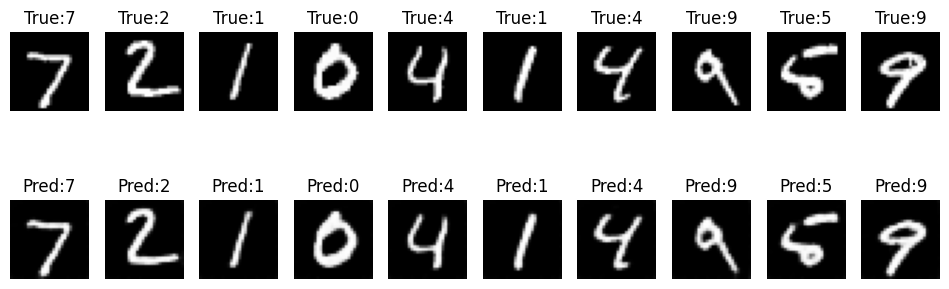

In [39]:
images,labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
  outputs,pred = model(images)
  _,predicted = torch.max(pred,1)

images = images.view(-1,1,28,28)
outputs = outputs.view(-1,1,28,28)

plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,10,i+1)
  plt.imshow(images[i].cpu().squeeze(), cmap='gray')
  plt.title(f"True:{labels[i]}")
  plt.axis('off')

  plt.subplot(2,10,i+11)
  plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
  plt.title(f"Pred:{predicted[i]}")
  plt.axis('off')

plt.show()